## 7.1 전자구조 계산 — 하트리-폭(HF) 방법

In [1]:
# 라이브러리 임포트
from qiskit import transpile
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.quantum_info import Pauli, SparsePauliOp, partial_trace
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorEstimator  # 호환성 수정: V1 Estimator → V2 StatevectorEstimator
from qiskit_aer import StatevectorSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_city
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 1단계: H2 해밀토니안 정의 (최소 기저, 2큐비트)
pauli_list = [Pauli('II'), Pauli('ZI'), Pauli('IZ'), Pauli('ZZ'), Pauli('XX')]
coefficients = [-1.0523732, 0.3979374, -0.3979374, -0.0112801, 0.1809312]
H2_hamiltonian = SparsePauliOp(pauli_list, coeffs=coefficients)

In [3]:
# 2단계: VQE용 매개변수 양자회로(앤사츠)
theta = Parameter('θ')
qc = QuantumCircuit(2)
qc.ry(theta, 0)   # Y축 회전으로 중첩 생성
qc.cx(0, 1)       # CNOT으로 두 큐비트 얽힘

In [4]:
# 3단계: COBYLA 최적화기로 VQE 설정
simulator = StatevectorSimulator()  # StatevectorSimulator 백엔드 사용
estimator = StatevectorEstimator()  # 호환성 수정: 기대값 측정용 V2 추정기

In [5]:
# 앤사츠·최적화기·추정기로 VQE 객체 생성
vqe = VQE(estimator, ansatz=qc, optimizer=COBYLA(maxiter=100))
result = vqe.compute_minimum_eigenvalue(H2_hamiltonian)

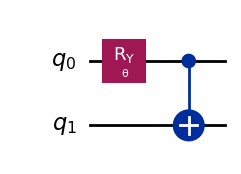

In [6]:
# 회로 시각화
qc.draw('mpl')
plt.show()

In [7]:
# 최적 매개변수 추출
optimal_params = result.optimal_point

In [8]:
# 최적 매개변수를 회로에 결합
optimal_circuit = qc.assign_parameters({theta: optimal_params[0]})

In [9]:
# 시뮬레이터용으로 회로 트랜스파일
transpiled_circuit = transpile(optimal_circuit, simulator)

In [10]:
# StatevectorSimulator 백엔드에서 회로를 실행해 상태벡터 획득
statevector_result = simulator.run(transpiled_circuit).result()

In [11]:
# 상태벡터 가져오기
statevector = statevector_result.get_statevector()

In [12]:
# 결과 출력
print(f"최적 매개변수: {optimal_params}")
print(f"바닥상태 에너지: {result.eigenvalue.real}")

최적 매개변수: [-1.5709208]
바닥상태 에너지: -1.244584498598395


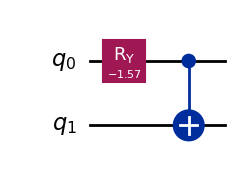

In [13]:
# 최적 회로 그리기
optimal_circuit.draw(output='mpl')
plt.show()

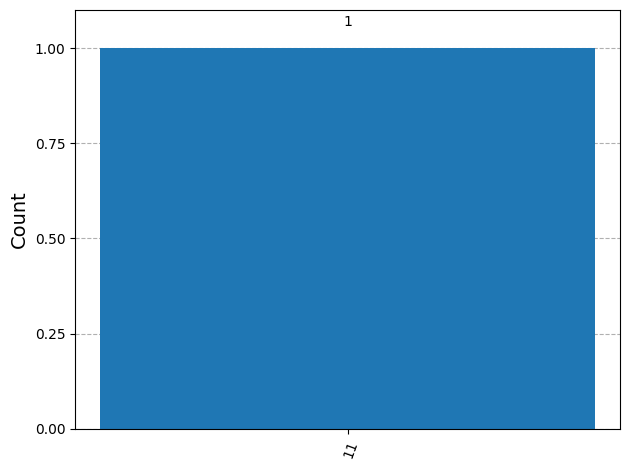

In [14]:
# 측정 결과 히스토그램
counts = simulator.run(optimal_circuit.measure_all(inplace=False)).result().get_counts()
plot_histogram(counts)
plt.show()

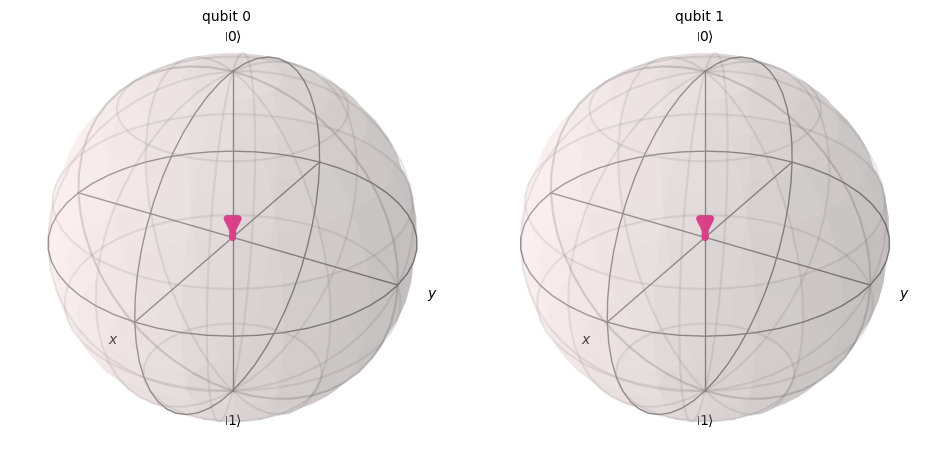

In [15]:
# 최종 상태의 블로흐 구 표현
plot_bloch_multivector(statevector)
plt.show()

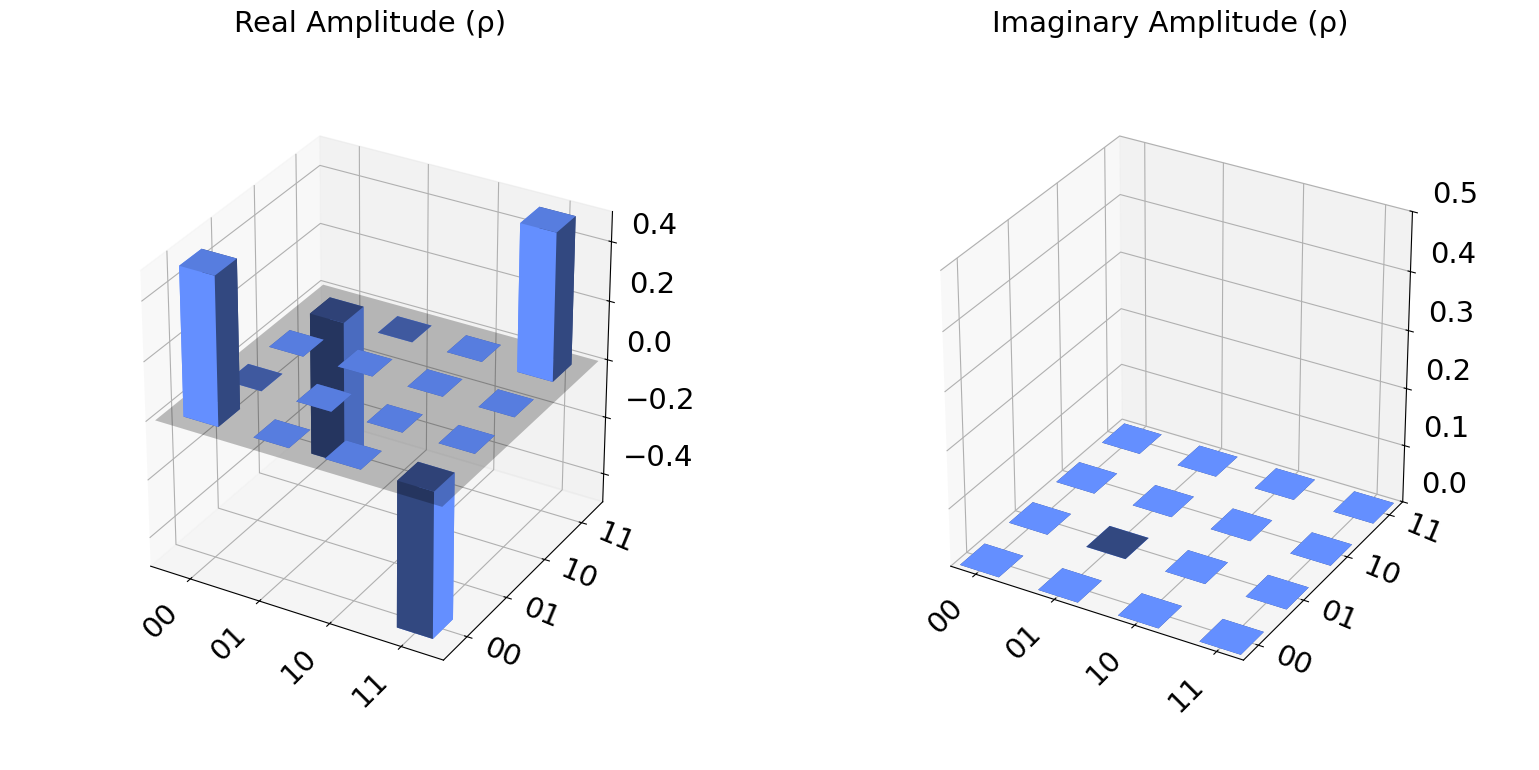

In [16]:
# 최종 상태의 state city 표현
plot_state_city(statevector)
plt.show()

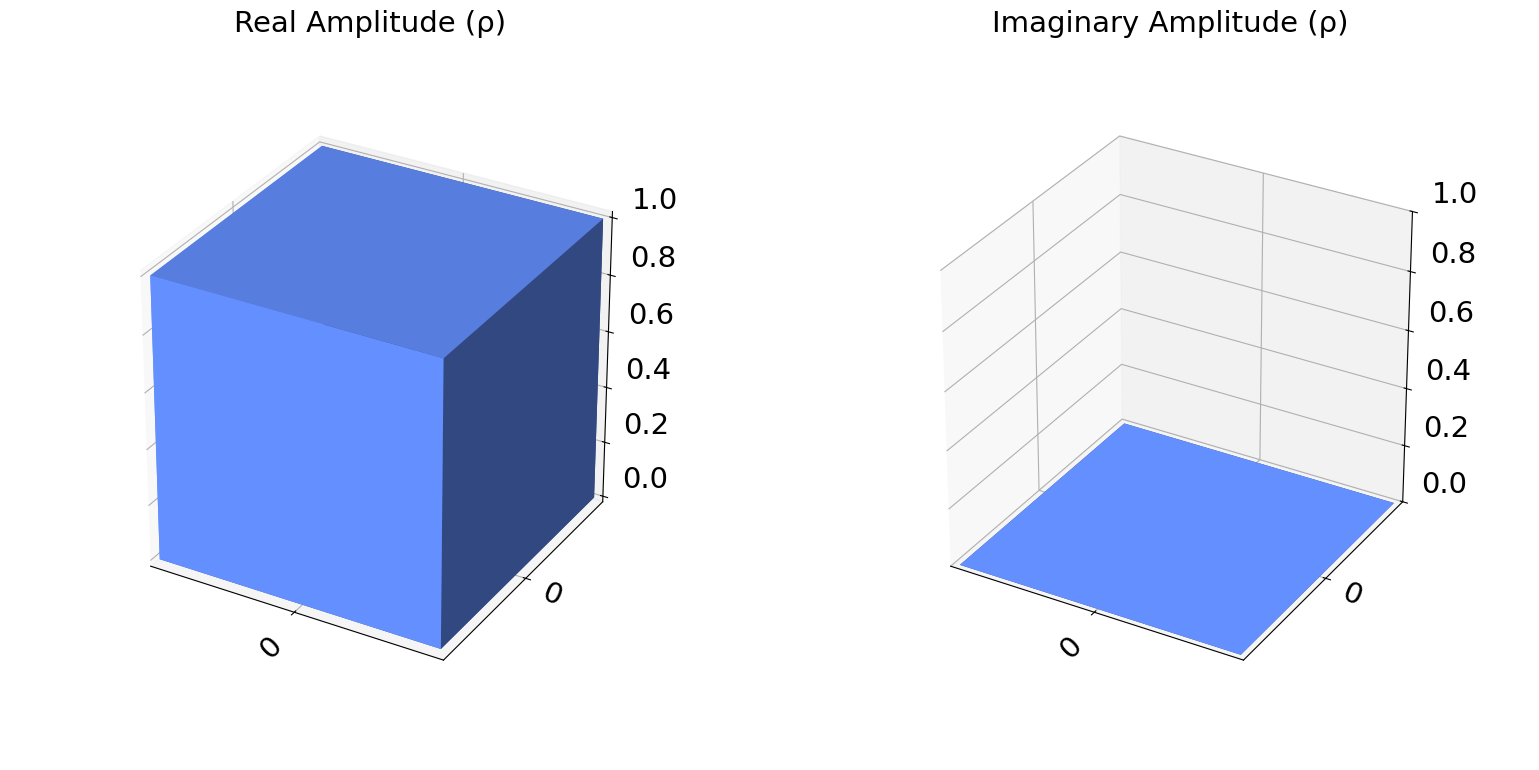

In [17]:
# 부분 대각합으로 부분계 분석 (더 복잡한 분석용)
subsystem_trace = partial_trace(statevector, [0, 1])
plot_state_city(subsystem_trace)
plt.show()